# 23/02


age         0.227075
sex         0.278467
cp          0.408945
trestbps    0.153490
chol        0.080285
fbs         0.003167
restecg     0.166343
thalach    -0.423817
exang       0.421355
oldpeak     0.424052
slope       0.333049
ca          0.463189
thal        0.526640
target      1.000000
Name: target, dtype: float64


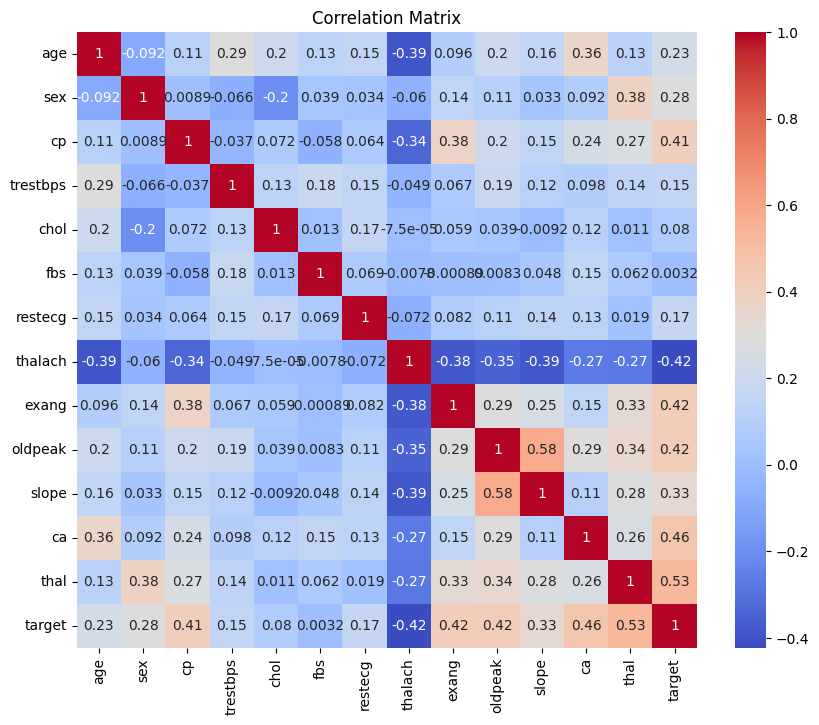

Rule-Based Accuracy: 0.8047138047138047


In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
# UCI repository CSV link (hosted on archive.ics.uci.edu)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names from UCI documentation
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, names=columns)

# Replace missing values ("?") with NaN and drop rows with NaN
df = df.replace("?", pd.NA)
df = df.dropna()
df = df.astype(float)

# Convert target to binary: 0 = no disease, 1 = disease present
df["target"] = (df["target"] > 0).astype(int)

# Rule-based classifier
def rule_based_classifier(row):
    score = 0

    # Relevância maior: talassemia, número de vasos, angina
    # if row["thal"] == 3:
    #     score += 2  # Talassemia normal (geralmente menos risco)
    if row["ca"] > 0:
        score += 2  # Mais vasos, maior risco (indicando obstrução)
    if row["exang"] == 1:
        score += 2  # Angina induzida é um forte indicativo de risco cardiovascular
    if row["oldpeak"] > 1.0:
        score += 1  # Depressão ST > 1 é um sinal importante de isquemia

    # Frequência cardíaca (thalach) e dor no peito (cp) também são importantes
    if row["thalach"] < 140:
        score += 1  # Frequência cardíaca baixa pode indicar risco
    if row["cp"] == 3 or row["cp"] == 4:
        score += 1  # Tipo 3 e 4 de dor no peito indicam maior risco cardiovascular

    # Classificação final: Se o score total for 4 ou mais, risco elevado (1), caso contrário (0)
    if score >= 4:
        return 1
    else:
        return 0


correlation_matrix = df.corr()
print(correlation_matrix["target"])

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
df["rule_prediction"] = df.apply(rule_based_classifier, axis=1)
print("Rule-Based Accuracy:", accuracy_score(df["target"], df["rule_prediction"]))

age                0.227075
sex                0.278467
cp                 0.408945
trestbps           0.153490
chol               0.080285
fbs                0.003167
restecg            0.166343
thalach           -0.423817
exang              0.421355
oldpeak            0.424052
slope              0.333049
ca                 0.463189
thal               0.526640
target             1.000000
rule_prediction    0.611466
Name: target, dtype: float64


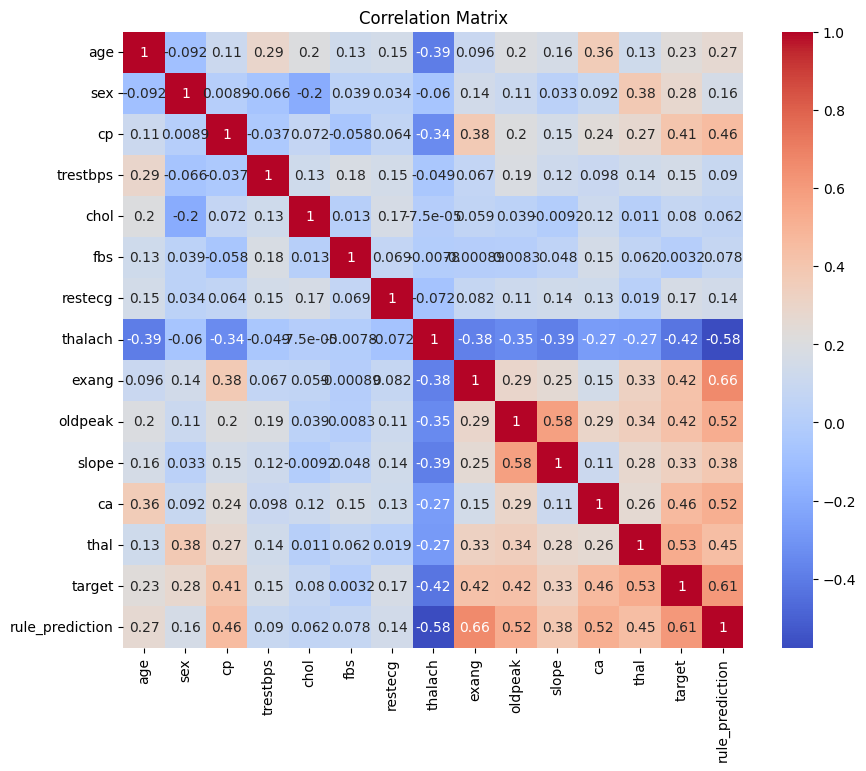

Rule-Based Accuracy: 0.8047138047138047

Machine Learning (SVM) Results:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        36
           1       0.88      0.88      0.88        24

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60

SVM Accuracy: 0.9


In [ ]:

correlation_matrix = df.corr()
print(correlation_matrix["target"])

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
df["rule_prediction"] = df.apply(rule_based_classifier, axis=1)
print("Rule-Based Accuracy:", accuracy_score(df["target"], df["rule_prediction"]))

# ML model (SVM)
X = df.drop(columns=["target", "rule_prediction"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
svm_model = SVC(kernel="linear")
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)

print("\nMachine Learning (SVM) Results:")
print(classification_report(y_test, y_pred))
print("SVM Accuracy:", accuracy_score(y_test, y_pred))

In [ ]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from itertools import combinations

# UCI repository CSV link (hosted on archive.ics.uci.edu)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names from UCI documentation
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, names=columns)

# Replace missing values ("?") with NaN and drop rows with NaN
df = df.replace("?", pd.NA)
df = df.dropna()
df = df.astype(float)

# Convert target to binary: 0 = no disease, 1 = disease present
df["target"] = (df["target"] > 0).astype(int)

# Rule-based classifier
def rule_based_classifier(row, features):
    score = 0

    # Relevância maior: talassemia, número de vasos, angina
    if "ca" in features and row["ca"] > 0:
        score += 2  # Mais vasos, maior risco (indicando obstrução)
    if "exang" in features and row["exang"] == 1:
        score += 2  # Angina induzida é um forte indicativo de risco cardiovascular
    if "oldpeak" in features and row["oldpeak"] > 1.0:
        score += 1  # Depressão ST > 1 é um sinal importante de isquemia

    # Frequência cardíaca (thalach) e dor no peito (cp) também são importantes
    if "thalach" in features and row["thalach"] < 140:
        score += 1  # Frequência cardíaca baixa pode indicar risco
    if "cp" in features and (row["cp"] == 3 or row["cp"] == 4):
        score += 1  # Tipo 3 e 4 de dor no peito indicam maior risco cardiovascular

    # Classificação final: Se o score total for 4 ou mais, risco elevado (1), caso contrário (0)
    if score >= 4:
        return 1
    else:
        return 0


# Get the list of columns (excluding 'target')
features = df.columns[:-1]

# Prepare to track the best performance
best_score = 0
best_features = []

# Loop through all combinations of features
for r in range(1, len(features) + 1):
    for feature_combination in combinations(features, r):
        # Apply the rule-based classifier with the selected features
        df["rule_prediction"] = df.apply(lambda row: rule_based_classifier(row, feature_combination), axis=1)

        # Calculate accuracy for this combination
        accuracy = accuracy_score(df["target"], df["rule_prediction"])

        # Update the best score and features if we find a better result
        if accuracy > best_score:
            best_score = accuracy
            best_features = feature_combination

print(f"Best combination of features: {best_features}")
print(f"Best rule-based accuracy: {best_score}")

KeyboardInterrupt: 

# 03/03

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def derivadas():
    a = np.sum((X_r - np.mean(X_r))*(Y_r - np.mean(Y_r)))/np.sum((X_r - np.mean(X_r))**2)
    b = np.mean(Y_r) - a*np.mean(X_r)
    return a,b

def calcula_erro(a,b):
    erro = 0
    for x_r, y_r in zip(X_r, Y_r):
        y_p = a * x_r + b
        erro += (y_r - y_p) ** 2
    return erro

data = pd.read_excel('data.xlsx')
X_r = data['x']
Y_r = data['y']

N = 100
A = np.linspace(-10,10,N)
B = np.linspace(-10,10,N)

erros = np.zeros(shape = (N,N))

menor_erro = calcula_erro(A[0],B[0])
melhor_a = A[0]
melhor_b = B[0]

for i,a in enumerate(A):
    for j,b in enumerate(B):
        erro = calcula_erro(a,b)
        erros[i][j] = erro
        if erro < menor_erro:
            menor_erro = erro
            melhor_a = a
            melhor_b = b



a,b = derivadas()
reta = a*X_r + b
melhor_reta = melhor_a * X_r + melhor_b
plt.plot(X_r,melhor_reta,'r',label = f'Melhor a: {melhor_a:.2f}\nMelhor b: {melhor_b:.2f}')
plt.plot(X_r,Y_r,'bo',label = 'Dados')
plt.plot(X_r,reta,'g',label = f'Derivadas: \na = {a}\nb = {b}')
plt.legend()
plt.figure()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
X, Y = np.meshgrid(A, B)
ax.plot_surface(X, Y, erros, cmap='viridis')
plt.show()


# 10/03

caso para 2d

Erro da regressao linear = somatoria((Yreal - Yprevisto)**2)

Yprevisto = a * Xreal + b

a: angulo da reta

b: ponto de onde a reta se inicia

Caso para multidimensoe

Y = w1 * x1 + w2 * x2 + w3 * x3 ... + b
W maiusculo = todos os w
X maiusculo = todos os x
Y = W * X + b

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target  # median house value in 100,000s

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", list(X.columns))

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Preprocess (standardize features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. Linear regression model
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = reg.predict(X_test_scaled)

# 6. Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print("R^2 Score:", r2)

# 7. Coefficients
coef = pd.Series(reg.coef_, index=X.columns)
print("\nTop features by absolute weight:")
print(coef.abs().sort_values(ascending=False).head(10))

# 8. Optional: Plot predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Prices (x100k)")
plt.ylabel("Predicted Prices (x100k)")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()



# 17/03

Regressão logistica

Yreal = 0 ou 1
Práximo de 0 ou próximo de 1

p = 1 / (1 + e ^ -(ax + b))
p = Yprevisto

Erro da regressao logistica = somatoria((Yreal - Yprevisto)**2)

Para 3d
Yprevisto = 1 / (1 + e^-(W * X + b))

(W * X + b) = formula da linha

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
def derivadas():
    a = np.sum((x_r - np.mean(x_r))*(y_r - np.mean(y_r)))/np.sum((x_r - np.mean(x_r))**2)
    b = np.mean(y_r) - a*np.mean(x_r)
    return a,b
def calcula_erro(a,b):
    erro = 0
    for k in range(len(x_r)):
        y_p = a * x_r[k] + b
        erro += (y_p - y_r[k]) ** 2
    return erro

data = pd.read_excel('data.xlsx')
x_r = data['x']
y_r = data['y']

N = 100
A = np.linspace(-10,10,N)
B = np.linspace(-10,10,N)

erros = np.zeros(shape = (N,N))
menor_a = A[0]
menor_b = B[0]
menor_erro = calcula_erro(A[0],B[0])
for i,a in enumerate(A):
    for j,b in enumerate(B):
        erro = calcula_erro(a,b)
        erros[i][j] = erro
        if erro < menor_erro:
            menor_erro = erro
            menor_a = a
            menor_b = b
a,b = derivadas()
melhor_reta = menor_a * x_r + menor_b
plt.plot(x_r,melhor_reta,'r',label= f'Melhor a: {menor_a:.2f}\nMelhor b: {menor_b:.2f}')
plt.plot(x_r, a*x_r + b,'g',label = f"Via derivadas: a = {a}, b = {b}")
plt.plot(x_r,y_r,'bo',label='Dados')
plt.legend()
plt.figure()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
X, Y = np.meshgrid(A, B)
ax.plot_surface(X, Y, erros, cmap='viridis')
plt.show()


In [ ]:
#!/usr/bin/env python3
"""
Standard Linear Regression on California Housing dataset
(no animation, just training and evaluation).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target  # median house value in 100,000s

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", list(X.columns))

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Preprocess (standardize features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. Linear regression model
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = reg.predict(X_test_scaled)

# 6. Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print("R^2 Score:", r2)

# 7. Coefficients
coef = pd.Series(reg.coef_, index=X.columns)
print("\nTop features by absolute weight:")
print(coef.abs().sort_values(ascending=False).head(10))

# 8. Optional: Plot predicted vs actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Prices (x100k)")
plt.ylabel("Predicted Prices (x100k)")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()


# 24/03

Função Erro depende de A e de B

classes terão sinais inversos (+ e -)

Erro MSE = 1

In [ ]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import imageio.v2 as imageio
from PIL import Image
from pathlib import Path
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

def sigmoid(z):
    return 1/(1+np.exp(-z))

def main(steps=24, lr=0.1, out_gif="combined_zline_plus_surface.gif", seed=0):
    data = load_breast_cancer()
    X_full = data.data
    y = data.target
    feature_names = data.feature_names
    i_radius = list(feature_names).index("mean radius")
    i_texture = list(feature_names).index("mean texture")
    X2 = X_full[:, [i_radius, i_texture]]

    scaler = StandardScaler()
    X = scaler.fit_transform(X2)

    w = np.zeros(2); b = 0.0
    x1_min, x1_max = X[:,0].min()-0.7, X[:,0].max()+0.7
    x2_min, x2_max = X[:,1].min()-0.7, X[:,1].max()+0.7
    xs_2d = np.linspace(x1_min, x1_max, 300)
    X1g, X2g = np.meshgrid(np.linspace(x1_min, x1_max, 60),
                           np.linspace(x2_min, x2_max, 60))

    outdir = Path("combo_frames"); outdir.mkdir(parents=True, exist_ok=True)
    frames = []
    elev, azim = 30, -60

    for t in range(steps):
        z = X @ w + b
        yhat = sigmoid(z)
        grad_w = (X.T @ (yhat - y)) / len(y)
        grad_b = np.mean(yhat - y)
        w -= lr * grad_w
        b -= lr * grad_b

        # 2D z-line view
        figA = plt.figure(figsize=(6.0,4.5))
        z_line = w[0]*xs_2d + b
        plt.plot(xs_2d, z_line, linewidth=2, label="z = w·x + b (vs x1)")
        plt.scatter(X[y==0,0], (X[y==0]@w + b), alpha=0.85, label="malignant (0): true z_i")
        plt.scatter(X[y==1,0], (X[y==1]@w + b), alpha=0.85, label="benign (1): true z_i")
        plt.axhline(0, linestyle="--")
        if abs(w[0]) > 1e-8:
            xb = -b / w[0]
            plt.axvline(xb, linestyle="--")
        plt.title(f"Raw linear scores z (step {t+1}/{steps}) | w=[{w[0]:.2f},{w[1]:.2f}], b={b:.2f}")
        plt.xlabel("{feature_names[i_radius]} (std)")
        plt.ylabel("score z")
        plt.ylim(-12, 12); plt.xlim(x1_min, x1_max)
        plt.legend(loc="upper left")
        plt.tight_layout()
        pathA = outdir / f"A_{t:03d}.png"
        plt.savefig(pathA, dpi=100)
        plt.close(figA)

        # 3D surface view
        Zsurf = sigmoid(w[0]*X1g + w[1]*X2g + b)
        figB = plt.figure(figsize=(6.0,4.5))
        ax3d = figB.add_subplot(111, projection="3d")
        ax3d.plot_surface(X1g, X2g, Zsurf, linewidth=0, antialiased=True, alpha=0.95)
        ax3d.contour(X1g, X2g, Zsurf, levels=[0.5], zdir='z', offset=0, linestyles='--', linewidths=1.0)
        ax3d.set_title("Probability surface σ(w·x + b)")
        ax3d.set_xlabel("{feature_names[i_radius]} (std)")
        ax3d.set_ylabel("{feature_names[i_texture]} (std)")
        ax3d.set_zlabel("P(y=1|x)")
        ax3d.set_zlim(0,1)
        ax3d.set_xlim(x1_min, x1_max)
        ax3d.set_ylim(x2_min, x2_max)
        ax3d.view_init(elev=elev, azim=azim)
        plt.tight_layout()
        pathB = outdir / f"B_{t:03d}.png"
        plt.savefig(pathB, dpi=100, bbox_inches="tight")
        plt.close(figB)

        # Compose horizontally
        from PIL import Image
        imA = Image.open(pathA).convert("RGB")
        imB = Image.open(pathB).convert("RGB")
        h = max(imA.height, imB.height)
        newA = Image.new("RGB", (imA.width, h), (255,255,255)); newA.paste(imA, (0,(h-imA.height)//2))
        newB = Image.new("RGB", (imB.width, h), (255,255,255)); newB.paste(imB, (0,(h-imB.height)//2))
        combo = Image.new("RGB", (newA.width + newB.width, h), (255,255,255))
        combo.paste(newA, (0,0)); combo.paste(newB, (newA.width,0))
        frame_path = outdir / f"combo_{t:03d}.png"; combo.save(frame_path, "PNG")
        frames.append(frame_path)

    with imageio.get_writer(out_gif, mode="I", duration=0.2) as writer:
        for fp in frames:
            writer.append_data(imageio.imread(fp))
    last = out_gif.replace(".gif","_last.png")
    Path(last).write_bytes(Path(frames[-1]).read_bytes())
    print("Saved:", out_gif, last)

if __name__ == "__main__":
    main()


In [ ]:
#!/usr/bin/env python3
"""
Standard Logistic Regression on Breast Cancer dataset
(no animation, just training and evaluation).
"""

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# 1. Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

print("Features shape:", X.shape)
print("Classes:", np.unique(y))

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Preprocess (standardize features)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 4. Logistic regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:,1]

# 6. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# 7. Coefficients (interpreting importance)
coef = pd.Series(clf.coef_[0], index=feature_names)
print("\nTop 10 features by magnitude:")
print(coef.abs().sort_values(ascending=False).head(10))

# 31/03

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, GridSearchCV

In [ ]:
data = load_breast_cancer()
x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train) # fit_transform tenta adequar a padronização aos dados de treino

x_test = scaler.transform(x_test) # transform tenta aplicar a padronização aprendida no conjunto de teste

grid = GridSearchCV(LogisticRegression(), param_grid = {}, cv=5, refit=True)
grid.fit(x_train, y_train)
print(grid.best_params_)

best_model = grid.best_estimator_
y_predict = best_model.predict(x_test)
print(accuracy_score(y_test, y_predict))
ConfusionMatrixDisplay.from_estimator(best_model, x_test, y_test)

data_df = pd.DataFrame(x, columns=data.feature_names)
data_df['target'] = y
data_df.head()
data_df.hist(figsize=(15,15), column=data_df.columns)
plt.show()

In [ ]:
probs = best_model.predict_proba(x_test)[:,1]
min_fn = float('inf')
min_t = 0.5

for t in np.linspace(0.01,0.9,100):
  probs = (probs > t).astype(int)
  tp,fp,fn,tn = confusion_matrix(y_test,probs).ravel()
  if fn < min_fn or (fn == min_fn and t > min_t):
    min_fn = fn
    min_t = t
probs = (probs > t).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test,probs)).plot()

print(min_t,min_fn)


# 07/04

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix


In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

X = pd.DataFrame(X, columns=data.feature_names)
y = pd.DataFrame(y, columns=['target'])

data = pd.concat([X,y], axis=1)
data.head()

In [ ]:
for feature in data.columns[:-1]:
  for target in data.target.unique():
    df = data[data['target'] == target]
    plt.hist(df[feature], bins=20, alpha=0.3,label=target)
    plt.legend()
    plt.title(feature)
  plt.show()

In [ ]:
y = np.array(y).ravel()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LogisticRegression(max_iter = 5000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter = 5000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

In [ ]:
probs = model.predict_proba(X_test_scaled)[:,1]
melhor_t = 0.5
tn, fp, melhor_fn, tp = confusion_matrix(y_test, y_pred > melhor_t).ravel()
for t in np.linspace(0.01,0.9):
  confusion = confusion_matrix(y_test,probs > t)
  tn,fp,fn,tp = confusion.ravel()
  if fn < melhor_fn or (fn == melhor_fn and t > melhor_t):
    melhor_fn = fn
    melhor_t = t
    conf = confusion
print(conf)
print(melhor_t)

Regularização Ridge ou L2

Erro = somatoria(y_real - y_previsto)^2

erro + alfa(a^2 + b^2)

aumenta o erro propositalmente do treino para tentar diminuir as variaveis A e B
melhor para features igualmente relevantes

erra mais no treino artificialmente para não viciar overfit

vantagem: quando tem varias features relevantes

Regularização Lasso ou L1

Erro = somatoria(y_real - y_previsto)^2

erro + alfa(raiz_quadrada(a^2 + b^2))

consegue zerar o erro e zerar variaveis

faz alguma feature ir à zero

faz feature selection

Elastic Net: combina L1 e L2

Erro = somatoria(y_real - y_previsto)^2 + (alfa(lambda(raiz(a^2 + b^^2) + (1 - lambda)(a^2 + b^2))))

In [ ]:
y = np.array(y).ravel()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter = 5000)

param_grid = [
    {
        'penalty': ['elasticnet'],
        'C': [0.01,0.1,1,10],
        'l1_ratio': np.linspace(0,1,100),
        'solver': ['saga'],
        'class_weight': ['balanced']
    },
    {
        'penalty': ['l2'],
        'C': [0.01,0.1,1,10],
        'solver': ['lbfgs'],
        'class_weight': ['balanced']
    },
    {
        'penalty': ['l1'],
        'C': [0.01,0.1,1,10],
        'solver': ['liblinear'],
        'class_weight': ['balanced']
    }
]

grid = GridSearchCV(model, param_grid, cv=5, scoring='recall', n_jobs=-1)
grid.fit(x_train_scaled, y_train)
model = grid.best_estimator_
print(grid.best_params_)
y_pred = model.predict(X_test_scaled)
print(accuracy_score(y_test, y_pred))

coef = pd.Series(model.coef_[0], index=X.columns)
print(coef.sort_values(ascending=False))

recall = tp / tp + fn

tp = true positive

fn = false negative

# 14/04

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay


In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter= 5000))
])

param_grid = [{
    'model__penalty': ['l1'],
    'model__C': np.logspace(-3, 3, 7),
    'model__solver': ['liblinear'],
    'model__class_weight': ['balanced']
},
{
    'model__penalty': ['l2'],
    'model__C': np.logspace(-3, 3, 7),
    'model__solver': ['lbfgs'],
    'model__class_weight': ['balanced']
},
{
    'model__penalty': ['elasticnet'],
    'model__C': np.logspace(-3, 3, 7),
    'model__l1_ratio': np.linspace(0, 1, 11),
    'model__solver': ['saga'],
    'model__class_weight': ['balanced']
}
]

In [ ]:
grid = GridSearchCV(pipe, param_grid, cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42), scoring = 'accuracy', n_jobs = -1 )

grid.fit(X_train, y_train)
grid.best_estimator_

In [ ]:
pd.DataFrame(grid.cv_results_)

In [ ]:
model = grid.best_estimator_
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [ ]:
from sklearn.datasets import make_circles
X,y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state = 42)
plt.scatter(X[:,0], X[:,1], c = y)
plt.show()
clf = LogisticRegression()
clf.fit(X,y)
xx, yy = np.meshgrid(np.linspace(-2,2,100),np.linspace(-2,2,100))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X[:,0], X[:, 1], c = y)
plt.show()

In [ ]:
def cria_circulo(linhas,colunas):
  matriz = []
  for i in range(linhas):
    linha = []
    for j in range(colunas):
      if (i - linhas // 2)**2 + (j - colunas //2)**2 <= (linhas // 2)**2:
        linha.append(1)
      else:
        linha.append(0)
    matriz.append(linha)
  return matriz
plt.imshow(cria_circulo(1000,1000))
plt.show()


In [ ]:
def cria_anel(linhas,colunas):
  matriz = []
  for i in range(linhas):
    linha = []
    for j in range(colunas):
      if (i - linhas // 2)**2 + (j - colunas //2)**2 <= (linhas // 2)**2 and (i - linhas // 2)**2 + (j - colunas //2)**2 >= (linhas // 2)**2 - 100*linhas:
        linha.append(1)
      else:
        linha.append(0)
    matriz.append(linha)
  return matriz
plt.imshow(cria_anel(1000,1000))
plt.show()


# 28/04

Classificação multiclasse = quando tem varias classes para se classificar

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay


In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names from UCI documentation
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal", "target"
]

data = pd.read_csv(url, names=columns, na_values="?")
data = data.replace('?',np.nan)
data = data.dropna()
y = data['target']
X = data.drop('target', axis = 1)
# y = (y > 0).astype(int)
y.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter= 5000))
])

param_grid = [{
    'model__penalty': ['l1'],
    'model__C': np.logspace(-3, 3, 7),
    'model__solver': ['liblinear'],
    'model__class_weight': ['balanced']
},
{
    'model__penalty': ['l2'],
    'model__C': np.logspace(-3, 3, 7),
    'model__solver': ['lbfgs'],
    'model__class_weight': ['balanced']
},
{
    'model__penalty': ['elasticnet'],
    'model__C': np.logspace(-3, 3, 7),
    'model__l1_ratio': np.linspace(0, 1, 11),
    'model__solver': ['saga'],
    'model__class_weight': ['balanced']
}
]

In [ ]:
grid = GridSearchCV(pipe, param_grid, cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42), scoring = 'accuracy', n_jobs = -1 )

grid.fit(X_train, y_train)
grid.best_estimator_

In [ ]:
model = grid.best_estimator_
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# 05/05

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names from UCI documentation
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal", "target"
]

data = pd.read_csv(url, names=columns)
data = data.replace("?", pd.NA)
data = data.dropna()
data.head()

y = data['target']
X = data.drop('target', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', None)
])
max_iter = 6000
param_grid = [
      {
          'model': [SVC()],
          'model__gamma': ['auto','scale'],
          'model__C': [0.001, 0.01, 0.1, 1, 10],
          'model__kernel': ['poly','linear','rbf','sigmoid']
      },
      {
        'model': [LogisticRegression(max_iter=max_iter, class_weight='balanced')],
        'model__penalty': ['l1'],
        'model__C': [0.001, 0.01, 0.1, 1, 10],
        'model__solver': ['liblinear']
    },
    {
        'model': [LogisticRegression(max_iter=max_iter, class_weight='balanced')],
        'model__penalty': ['l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10],
        'model__solver': ['lbfgs']
    },
    {
        'model': [LogisticRegression(max_iter=max_iter, class_weight='balanced')],
        'model__penalty': ['elasticnet'],
        'model__C': [0.001, 0.01, 0.1, 1, 10],
        'model__solver': ['saga'],
        'model__l1_ratio': np.linspace(0, 1, 11),
    }
]

In [ ]:
grid = GridSearchCV(pipe, param_grid, cv = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42), scoring = 'accuracy', n_jobs = -1)

grid.fit(X_train, y_train)
model = grid.best_estimator_
preds = model.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, preds)}')
ConfusionMatrixDisplay.from_predictions(y_test,preds)
plt.show()

In [ ]:
from seaborn import pairplot
pairplot(data, hue='target', palette = 'viridis')
plt.show()

# 12/05

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [ ]:
media_1 =[1,1]
cov_1 = [[1,0],[0,1]]
data_1 = np.random.multivariate_normal(media_1,cov_1,500)

media_2 =[2,8]
cov_2 = [[1,0.5],[0.5,1]]
data_2 = np.random.multivariate_normal(media_2,cov_2,500)

media_3 =[9,3]
cov_3 = [[1,-0.8],[-0.8,1]]
data_3 = np.random.multivariate_normal(media_3,cov_3,500)

data = np.concatenate((data_1,data_2,data_3),axis=0)

plt.scatter(data[:,0],data[:,1])
plt.grid()
plt.show()

In [ ]:
silhouette = []
for k in range(2,10):
  kmeans = KMeans(n_clusters=k,random_state=0)
  kmeans.fit(data)
  labels = kmeans.labels_
  coef = silhouette_score(data,labels)
  silhouette.append(coef)
  centers = kmeans.cluster_centers_
  plt.scatter(data[:,0],data[:,1],c=labels)
  plt.scatter(centers[:,0],centers[:,1], marker='x', c='red')
  plt.title(f'{k} clusters')
  plt.grid()
  plt.show()
plt.plot(range(2,10),silhouette,label=f'Best K = {np.argmax(silhouette) + 2}')
plt.title('Silhouette score')
plt.xlabel('Number of scores')
plt.legend()
plt.grid()
plt.show()

# 19/05

In [ ]:
best_k = np.argmax(silhouette) + 2
cluster = KMeans()
cluster.fit_predict(data)
labels = cluster.labels_
centers = cluster.cluster_centers_
plt.scatter(data[:,0],data[:,1],c=labels)
plt.scatter(centers[:,0],centers[:,1], marker='x', c='red')
plt.grid()
plt.show()

# 18/08


Arvores: sequencia de estruturas condicionais

Podem sofer overfitting

Random forest: Para evitar overfitting podemos fazer mais arvores com diferentes conjuntos de dados e diferentes features e depois realizar uma votação

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [ ]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, stratify=y,random_state= 42)
forest = RandomForestClassifier(
    n_estimators = 1000,
    max_features= 4
)
forest.fit(X_train,y_train)
preds = forest.predict(X_test)
accuracy_score(preds,y_test)
print(forest)

salva o modelo

In [ ]:
import joblib

joblib.dump(forest,'model.pkl')

In [ ]:
model= joblib.load("model.pkl")

In [ ]:
Rede neural: conjunto de regressões lineares com formulas variadas

# 25/08

Y = tudo que eu to prevendo
regressão linear
y = w1 * x1 + w2 * x2 + b

cada x é uma feature/coluna

regressão linear: a camada da frente passa várias regressões lineares para a camada de trás

camada final = p1 * z1 * p2 * z2 * p3 * z3 + b

função de ativação: aplica uma função em z1, z2, z3, etc; antes de passar para a frente

z valor final da rede neural

z = (p * (1 / (1 + e ^ -(w11x1 + w12x2 + w13x3 + b)))) *
(p * (1 / (1 + e ^ -(w21x1 + w22x2 + w23x3 + b)))) *
(p * (1 / (1 + e ^ -(w31x1 + w32x2 + w33x3 + b)))) *

# 01/09

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt

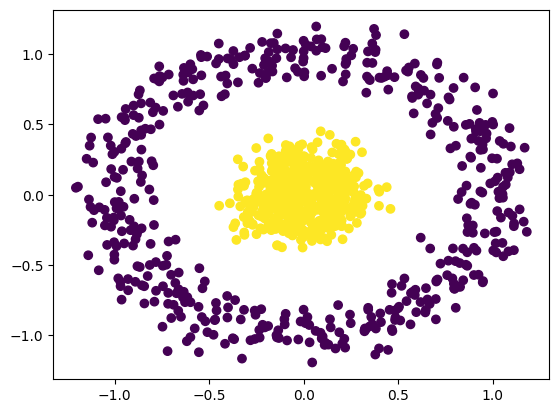

In [ ]:
X, y = make_circles(n_samples = 1000, noise = 0.1, factor = 0.2)
plt.scatter(X[:,0], X[:,1], c = y)
plt.show()

In [ ]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'
print(device)

cuda


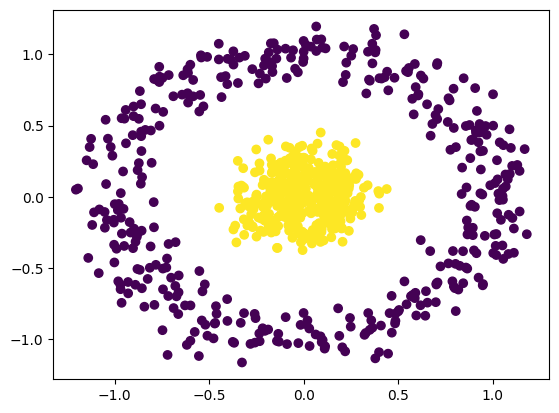

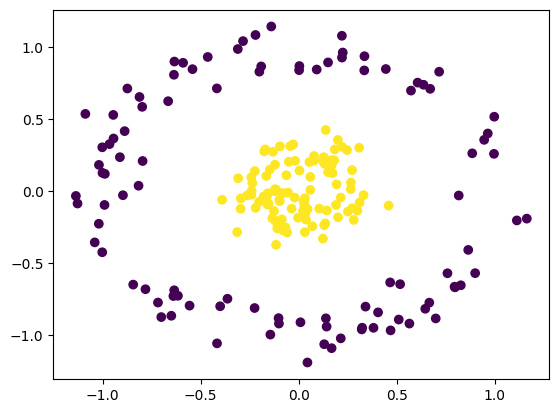

In [ ]:
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size = 0.2, stratify=y)

plt.scatter(X_train[:,0], X_train[:,1], c = y_train)
plt.show()
plt.scatter(X_test[:,0], X_test[:,1], c = y_test)
plt.show()



In [ ]:
X_train = torch.tensor(X_train, dtype = torch.float32).to(device)
X_test = torch.tensor(X_test, dtype = torch.float32).to(device)
y_train = torch.tensor(y_train, dtype = torch.float32).view(-1,1).to(device)
y_test = torch.tensor(y_test, dtype = torch.float32).view(-1,1).to(device)

/tmp/ipykernel_1073/704211131.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype = torch.float32).to(device)
/tmp/ipykernel_1073/704211131.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype = torch.float32).to(device)
/tmp/ipykernel_1073/704211131.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(y_train, dtype = torch.float32).view(-1,1).to(device)
/tmp/ipykernel_1073/704211131.py:4: UserWarning: To copy construct from a tensor, it is rec

In [ ]:
class show_the_balls(nn.Module):
  def __init__(self,hidden = 3):
    super().__init__()
    self.hidden = hidden
    self.layer1 = nn.Linear(2,hidden)
    self.layer2 = nn.Linear(hidden,1)

  def forward(self,x):
    z = self.layer1(x)
    fz = torch.sigmoid(z)
    res = self.layer2(fz)
    return res

BOLA = show_the_balls(hidden = 10)
BOLA.to(device)

show_the_balls(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=1, bias=True)
)

a derivada me diz que eu devo diminuir ou aumentar o w11 para reduzir o erro

"apontando para onde andar"

ela diz o que fazer, mas não o quanto aumentar ou diminuir

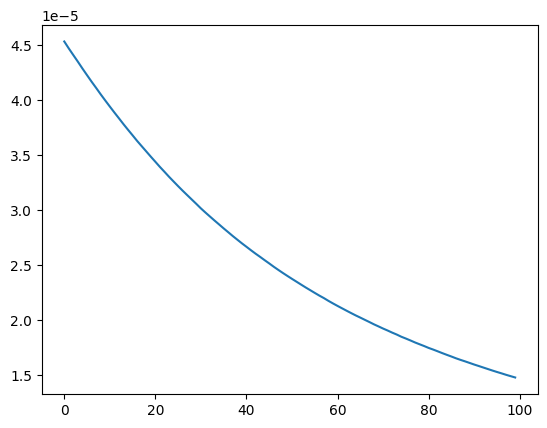

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(BOLA.parameters(), lr = 0.01)
erro = []
for i in range(100):
  optimizer.zero_grad()
  preds = BOLA.forward(X_train)
  loss = criterion(preds,y_train)
  loss.backward()
  optimizer.step()
  erro.append(loss.item())

plt.plot(erro)
plt.show()

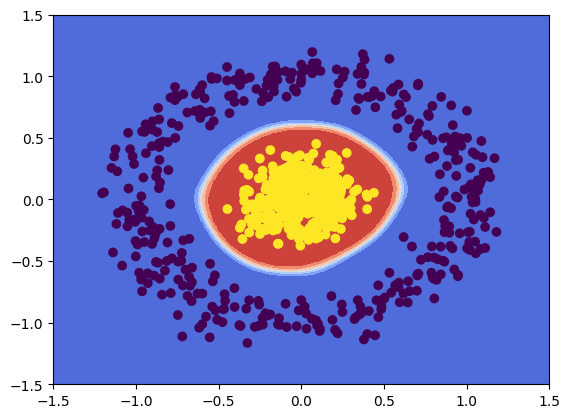

In [ ]:
xx, yy = np.meshgrid(np.linspace(-1.5,1.5,100),np.linspace(-1.5,1.5,100))
grid = torch.tensor(np.c_[xx.ravel(),yy.ravel()], dtype= torch.float32).to(device)
with torch.no_grad():
  preds = torch.sigmoid(BOLA.forward(grid)).cpu().numpy()
plt.contourf(xx,yy, preds.reshape(xx.shape), cmap = "coolwarm")
plt.scatter(X_train[:,0].cpu().numpy(), X_train[:,1].cpu().numpy(), c=y_train.cpu().numpy())



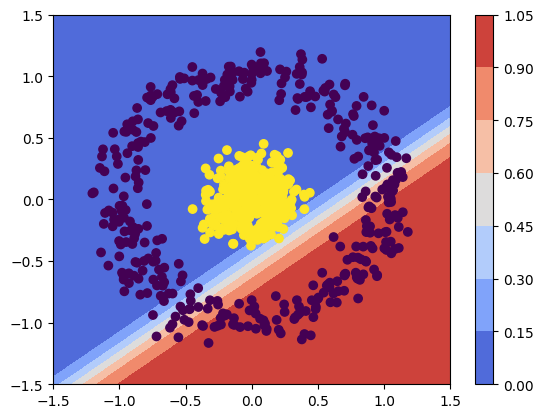

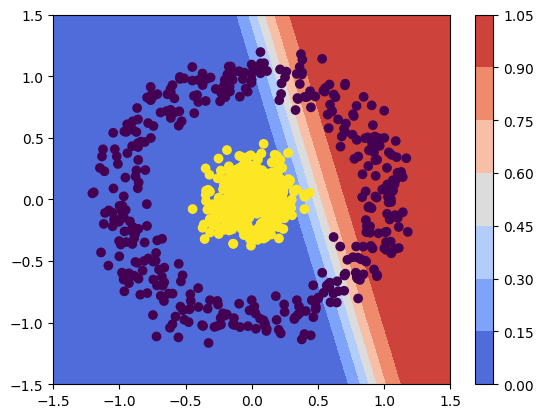

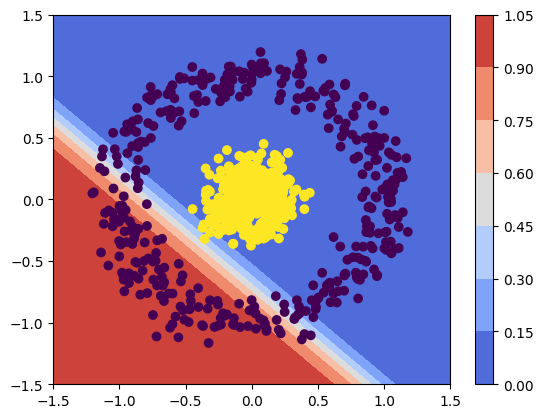

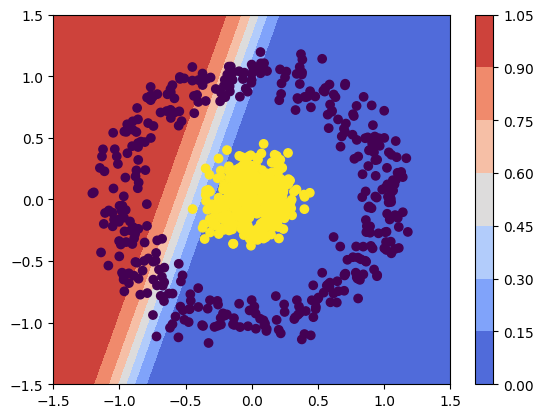

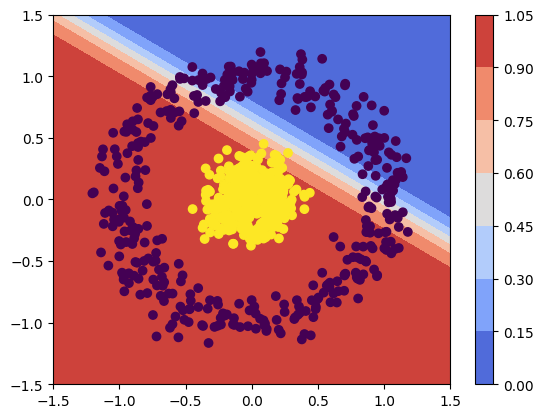

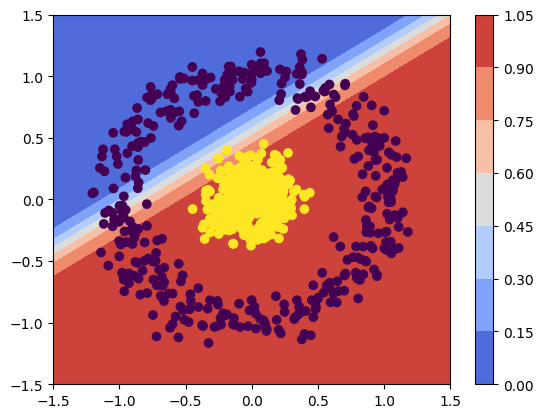

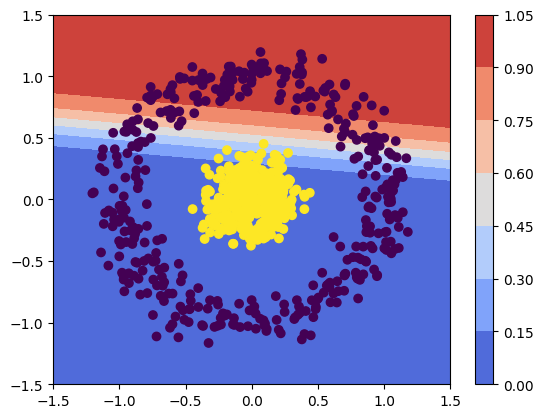

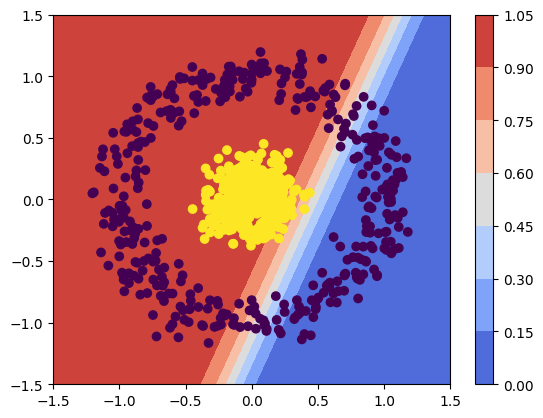

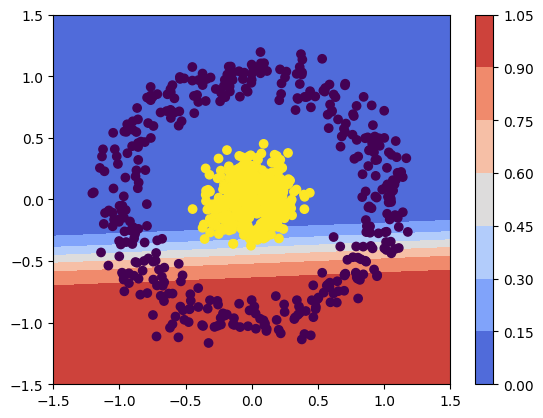

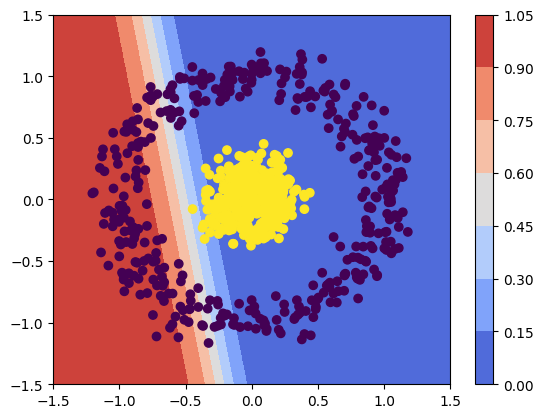

In [ ]:
xx, yy = np.meshgrid(np.linspace(-1.5,1.5,100),np.linspace(-1.5,1.5,100))
grid = torch.tensor(np.c_[xx.ravel(),yy.ravel()], dtype= torch.float32).to(device)
for i in range(BOLA.hidden):
  with torch.no_grad():
    preds = torch.sigmoid(BOLA.layer1(grid))[:,i].cpu().numpy()
  plt.contourf(xx,yy, preds.reshape(xx.shape), cmap = "coolwarm")
  plt.colorbar()
  plt.scatter(X_train[:,0].cpu().numpy(), X_train[:,1].cpu().numpy(), c=y_train.cpu().numpy())
  plt.show()



# 22/09



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)


torch.Size([1, 28, 28]) 5


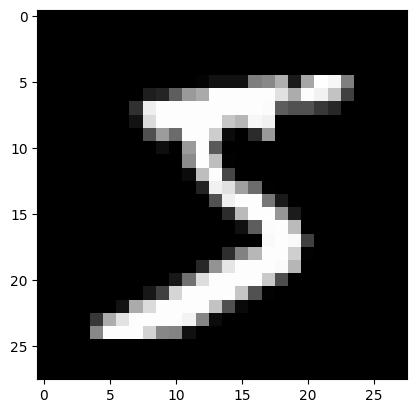

In [ ]:
img, label = train_dataset[0]
print(img.size(), label)
plt.imshow(img.squeeze(), cmap='gray')
plt.show()

In [ ]:
class transformice(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(784, 256)
    self.layer2 = nn.Linear(256,128)
    self.layer3 = nn.Linear(128,10)

  def forward(self,x):
    x = self.layer1(x)
    x = torch.relu(x)
    x = self.layer2(x)
    x = torch.relu(x)
    x = self.layer3(x)
    x = torch.relu(x)
    return x

digitos = transformice().to(device)

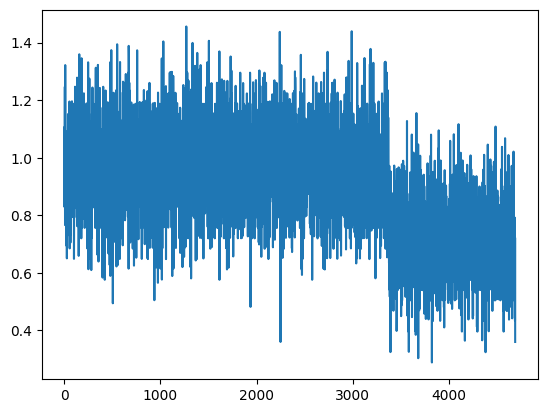

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(digitos.parameters(), lr=0.001)
erro = []
for i in range(5):
  for image, label in train_loader:
    image = image.to(device)
    preds = digitos(image.view(-1, 784))
    loss  = criterion(preds, label.to(device))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    erro.append(loss.item())
plt.plot(erro)